# Project Work part 1 - Dashboard basics

## Reservoir data

In this notebook, the reservoir dataset is imported and explored using Pandas. The column names are translated to understandable English names, and the data is visualized both separately and together.

**Author:** Alina Shah  
**GitHub:** https://github.com/59762/IND320-59762  
**Streamlit:** https://ind320-59762.streamlit.app/

---

### AI Usage Declaration

I used Claude as an AI assistant during this project. It helped me:
- Understand the correct column names in the CSV and how to rename them
- Structure the notebook layout and choose suitable plot types
- Set up the Streamlit multi-page app structure and debug errors

All code was reviewed, run, and understood by me before submission.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the reservoir data
df = pd.read_csv("data/reservoirs.csv")

# Check that the data was loaded correctly
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14877 non-null  str    
 1   omrType                   14877 non-null  str    
 2   omrnr                     14877 non-null  int64  
 3   iso_aar                   14877 non-null  int64  
 4   iso_uke                   14877 non-null  int64  
 5   fyllingsgrad              14877 non-null  float64
 6   kapasitet_TWh             14877 non-null  float64
 7   fylling_TWh               14877 non-null  float64
 8   neste_Publiseringsdato    14877 non-null  str    
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsgrad      14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB
None


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## Rename columns

The column names are in Norwegian. We rename them to understandable English names.

In [2]:
# Rename columns to understandable English names
df = df.rename(columns={
    "dato_Id":                  "date",
    "fyllingsgrad":             "fill_level",
    "kapasitet_TWh":            "capacity_TWh",
    "fylling_TWh":              "stored_energy_TWh",
    "fyllingsgrad_forrige_uke": "fill_level_previous_week",
    "endring_fyllingsgrad":     "change_in_fill_level",
})

# Convert date columns to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Check the renamed columns
print(df.columns.tolist())
df.head()

['date', 'omrType', 'omrnr', 'iso_aar', 'iso_uke', 'fill_level', 'capacity_TWh', 'stored_energy_TWh', 'neste_Publiseringsdato', 'fill_level_previous_week', 'change_in_fill_level']


,date,omrType,omrnr,iso_aar,iso_uke,fill_level,capacity_TWh,stored_energy_TWh,neste_Publiseringsdato,fill_level_previous_week,change_in_fill_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## Basic summary

The first rows of the dataset are displayed to inspect the structure and values. A statistical summary is also shown for the numerical values.

In [3]:
# Display the first 10 rows
display(df.head(10))

# Statistical summary of numerical values
display(df.describe().T)

,date,omrType,omrnr,iso_aar,iso_uke,fill_level,capacity_TWh,stored_energy_TWh,neste_Publiseringsdato,fill_level_previous_week,change_in_fill_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
5,2017-11-05,EL,4,2017,44,0.794520,21.079208,16.747847,0001-01-01T00:00:00,0.804085,-0.009565
6,2003-03-02,EL,1,2003,9,0.195046,6.003264,1.170914,0001-01-01T00:00:00,0.222014,-0.026968
7,2000-11-26,EL,4,2000,47,0.866371,21.079208,18.262426,0001-01-01T00:00:00,0.884963,-0.018591
8,2016-09-04,EL,1,2016,35,0.890967,6.003264,5.348708,0001-01-01T00:00:00,0.881946,0.009021
9,2023-08-13,EL,5,2023,32,0.836849,17.390587,14.553301,2023-08-23T13:00:00,0.776765,0.060084


,count,mean,min,25%,50%,75%,max,std
date,14877,2010-11-07 00:00:00,1995-01-08 00:00:00,2002-12-08 00:00:00,2010-11-07 00:00:00,2018-10-07 00:00:00,2026-09-06 00:00:00,NaN
omrnr,14877.0,2.333333,0.0,1.0,2.0,3.0,5.0,1.490762
iso_aar,14877.0,2010.346038,1995.0,2002.0,2010.0,2018.0,2026.0,9.146696
iso_uke,14877.0,26.405929,1.0,13.0,26.0,39.0,53.0,15.01791
fill_level,14877.0,0.618852,0.05516,0.456234,0.648049,0.802135,1.020072,0.21485
capacity_TWh,14877.0,29.14586,6.003264,17.390587,23.237715,34.04359,87.43758,22.73907
stored_energy_TWh,14877.0,18.139713,0.331142,7.321973,14.501389,22.20353,84.54482,15.966211
fill_level_previous_week,14877.0,0.61889,0.05516,0.456356,0.648114,0.802133,1.020037,0.214843
change_in_fill_level,14877.0,-0.000038,-0.242484,-0.022395,-0.007072,0.016277,0.336623,0.031385


## Plot each numerical column separately

The numerical reservoir variables are plotted separately to make their individual scales and variation easier to inspect.

C:\Users\Alina\AppData\Local\Temp\ipykernel_13788\467900217.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


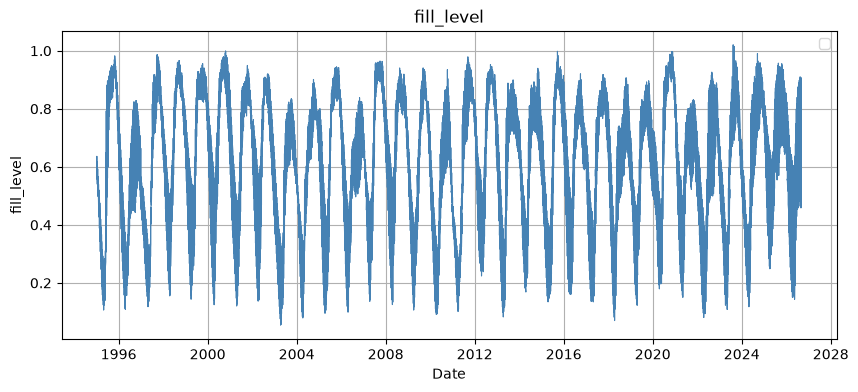

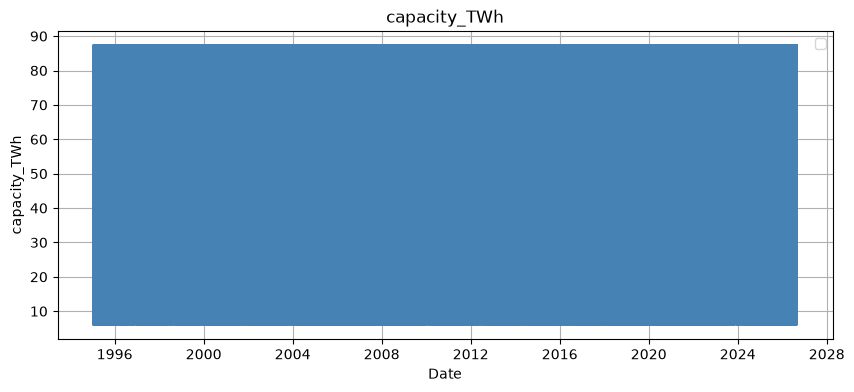

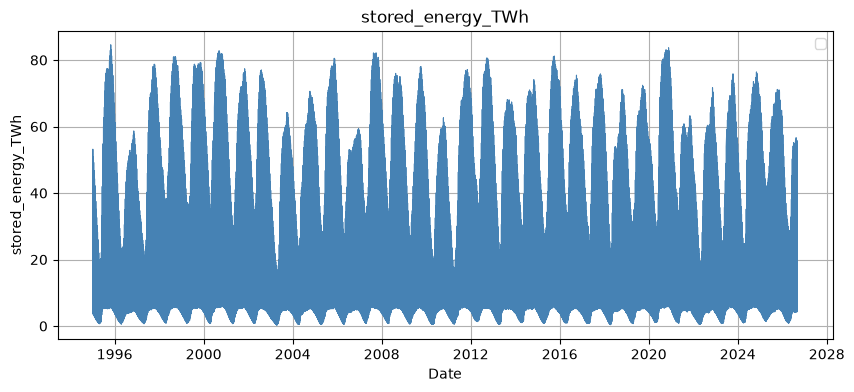

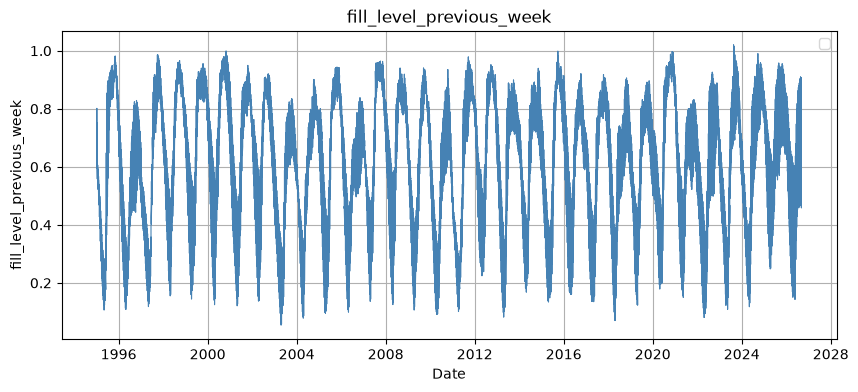

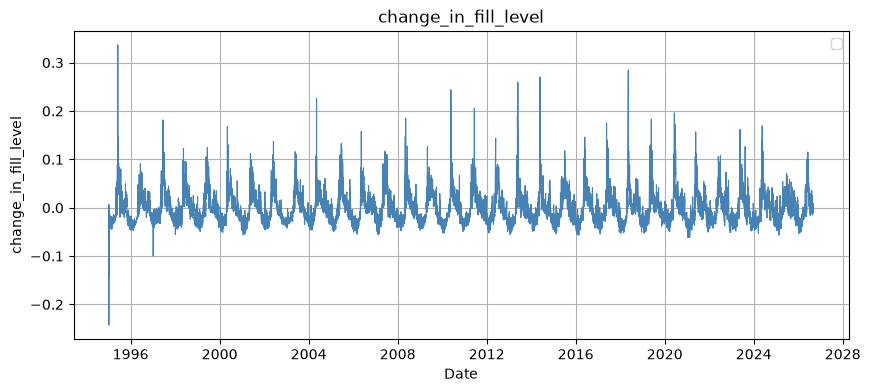

In [4]:
# Sort data by date
df_sorted = df.sort_values(["date"])

# Select relevant numerical reservoir columns
plot_columns = [
    "fill_level",
    "capacity_TWh",
    "stored_energy_TWh",
    "fill_level_previous_week",
    "change_in_fill_level"
]

# Plot each column separately
for column in plot_columns:
    plt.figure(figsize=(10, 4))

    plt.plot(
        df_sorted["date"],
        df_sorted[column],
        linewidth=0.8,
        color="steelblue",
    )

    plt.title(column)
    plt.xlabel("Date")
    plt.ylabel(column)
    plt.legend()
    plt.grid(True)
    plt.show()

## Plot all variables together

The numerical variables have different scales and units. To make them comparable in the same plot, each variable is normalized to a range from 0 to 1 using the min-max normalization.

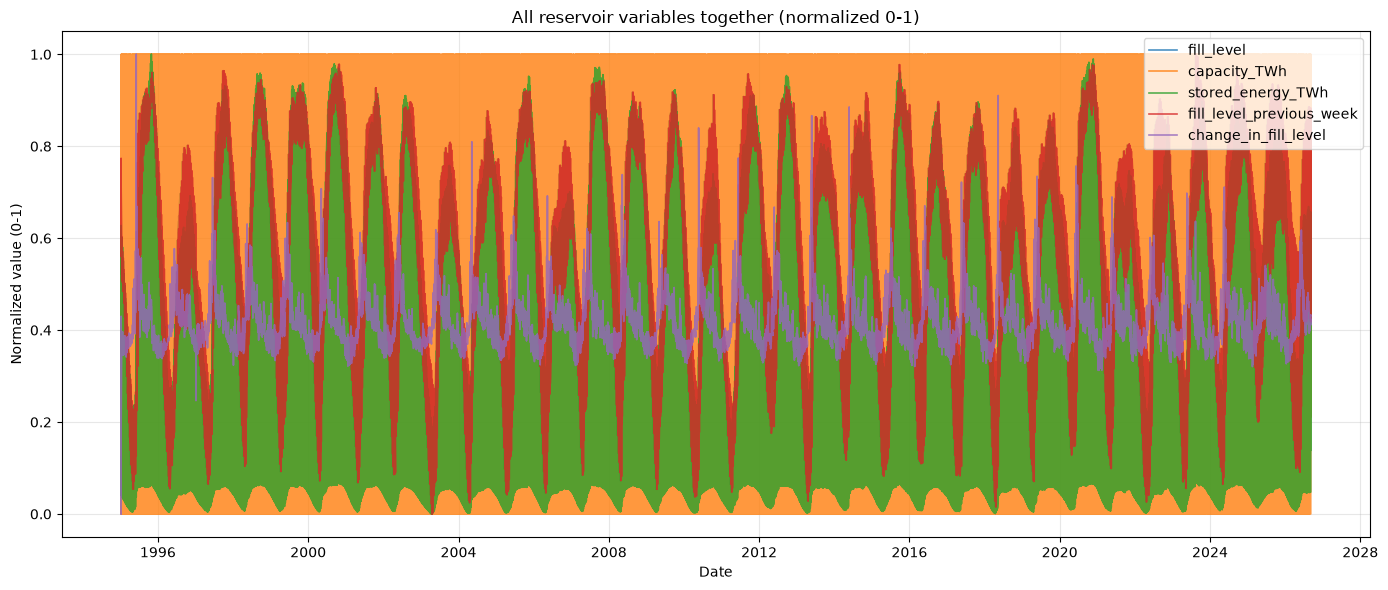

In [5]:
# Sort data by date
df_sorted = df.sort_values(["date"]).reset_index(drop=True)

# Create a copy for normalized values
df_norm = df_sorted.copy()

# Min-max normalize each variable to a scale from 0 to 1
for col in plot_columns:
    mn = df_sorted[col].min()
    mx = df_sorted[col].max()

    df_norm[col] = (df_sorted[col] - mn) / (mx - mn)

# Plot all normalized variables together
plt.figure(figsize=(14, 6))

for col in plot_columns:
    plt.plot(
        df_sorted["date"],
        df_norm[col],
        linewidth=1.2,
        alpha=0.8,
        label=col
    )

plt.title("All reservoir variables together (normalized 0-1)")
plt.xlabel("Date")
plt.ylabel("Normalized value (0-1)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Log – Compulsory Work

**Jupyter Notebook experience:**  
I started by loading `reservoirs.csv` into pandas and printing the original column names. All column names were in Norwegian, so I created a rename dictionary to convert them to clear English names. I also converted the date column from plain text to a proper datetime type using `pd.to_datetime()`, which is necessary for plotting dates correctly on the x-axis.

After renaming, I printed the dataset info and descriptive statistics to understand the data. The dataset has 1653 rows, covering weekly reservoir measurements from January 1995 to September 2026. The columns include the weekly fill level, total capacity in TWh, actual stored energy in TWh, the previous week's fill level, and the week-on-week change.

For plotting, I first made individual plots for each of the five numeric columns. This makes it easy to read each series clearly. Then I made a combined plot using min-max normalization so all variables could be shown on the same 0–1 scale — this is the best approach here because the columns have very different units and scales.

**Streamlit experience:**  
I built the app with four pages: a home page (`app.py`) and three pages in the `pages/` folder. Streamlit automatically picks up files in `pages/` and adds them to the sidebar. I used `@st.cache_data` on the data loading function so the CSV file is only read once, making the app faster. The Table page shows the first month of data with a sparkline for each column using `LineChartColumn`. The Plot page has a dropdown to select a column and a slider to pick a month range, and the About page has project info and links.

**AI usage:**  
I used Claude to help me identify the correct column names in the CSV, structure the notebook sections, debug errors in the Streamlit pages, and understand how Streamlit's multi-page setup works. All code was tested and run by me.